# Groepsnummer: G09

**Voornaam:** Arne  
**Familienaam:** Bogaert  
**Studentennummer:** 399518ab

**Analyses in dit notebook:**
- Reeks 1 Analyse 1
- Reeks 2 Analyse 1

## Reeks 1 Analyse 1

In deze analyse halen we voor 1 telpaal de dagelijkse fietstellingen op uit de DWH. Daarna passen we anomaliedetectie toe om opvallende dagen te vinden waarop het aantal fietsers sterk afwijkt van het normale patroon.


### Stap 1: Benodigde libraries importeren en verbinding met de DWH voorbereiden

We importeren de libraries die we nodig hebben voor data-ophaling, dataverwerking, visualisatie, modeltraining en evaluatie.


In [80]:
# Standaardbibliotheken
from pathlib import Path
import sys

# Data-analyse en visualisatie
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Omgevingsvariabelen laden
from dotenv import load_dotenv

load_dotenv()

# Projectroot zoeken zodat imports uit de DWH-map werken
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'DWH').exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# Herbruikbare functies uit het project importeren
from DWH.connection.connect import get_engine, getData

# Grafieken iets mooier maken
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

### Stap 2: De telpaal kiezen

De opdracht zegt dat de naam van de telpaal een parameter moet zijn. Daarom zetten we de telpaalnaam in een aparte variabele. Zo kan je makkelijk een andere telpaal testen.


In [81]:
# Is een parameter dus vervang met gevraagde telpaal
TELPAAL_NAAM = "Aalst - Fietspad Merestraat (Noord)"

print(f"Gekozen telpaal: {TELPAAL_NAAM}")


Gekozen telpaal: Aalst - Fietspad Merestraat (Noord)


Als je de exacte naam van een telpaal niet kent, kan je eerst een lijst van beschikbare telpalen opvragen.


In [82]:
engine = get_engine()

TELPALEN_QUERY = """
SELECT TOP 20 CountingPointName
FROM DimCountingPoint
ORDER BY CountingPointName
"""

beschikbare_telpalen = getData(engine, TELPALEN_QUERY)
beschikbare_telpalen


,CountingPointName
0,Aalst - Fietspad Merestraat (Noord)
1,Aalst F414 Fietspad Merestraat (West)
2,Aalst F414 Fietspad Merestraat (Zuid)
3,Aalter - Knokkebaan
4,Aarschot - Ter Heidelaan
5,Antwerpen - Amsterdamstraat
6,Antwerpen - Binnensingel Oost (Posthofbrug)
7,Antwerpen - Binnensingel West (Uitbreidingsstr...
8,Antwerpen - Borsbeeksebrug
9,Antwerpen - Brouwersvliet


### Stap 3: De nodige data ophalen uit de DWH

We halen de dagelijkse tellingen op voor 1 telpaal. We voegen ook datumkenmerken toe uit `DimDate`, omdat die nuttig zijn voor anomaliedetectie. Bijvoorbeeld: weekends, feestdagen en maand kunnen invloed hebben op het normale aantal fietsers.


In [83]:
SQL_QUERY = f"""
SELECT
    cp.CountingPointName,
    d.DateKey,
    d.FullDateAlternateKey AS [Date],
    d.DayOfWeek,
    d.EnglishDayNameOfWeek,
    d.Month,
    d.EnglishMonthName,
    d.IsWeekend,
    d.IsHoliday,
    fc.DirectionInCounts,
    fc.DirectionOutCounts,
    fc.TotalCounts
FROM FactCountings fc
JOIN DimCountingPoint cp ON fc.CountingPointID = cp.CountingPointID
JOIN DimDate d ON fc.DateKey = d.DateKey
WHERE cp.CountingPointName = '{TELPAAL_NAAM}'
ORDER BY d.FullDateAlternateKey
"""


In [84]:
# Data effectief ophalen uit de DWH
df = getData(engine, SQL_QUERY)

# Extra controle: we stoppen als er geen data is
if df is None or df.empty:
    raise ValueError(
        "Er werd geen data opgehaald. Controleer of de database draait en of de telpaalnaam exact klopt."
    )

# Datatypes corrigeren en sorteren op datum
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Aantal opgehaalde records: {len(df)}")
df.head()


Aantal opgehaalde records: 2281


,CountingPointName,DateKey,Date,DayOfWeek,EnglishDayNameOfWeek,Month,EnglishMonthName,IsWeekend,IsHoliday,DirectionInCounts,DirectionOutCounts,TotalCounts
0,Aalst - Fietspad Merestraat (Noord),20200101,2020-01-01,3,Wednesday,1,January,False,True,22,16,38
1,Aalst - Fietspad Merestraat (Noord),20200102,2020-01-02,4,Thursday,1,January,False,False,58,54,112
2,Aalst - Fietspad Merestraat (Noord),20200103,2020-01-03,5,Friday,1,January,False,False,53,44,97
3,Aalst - Fietspad Merestraat (Noord),20200104,2020-01-04,6,Saturday,1,January,True,False,52,52,104
4,Aalst - Fietspad Merestraat (Noord),20200105,2020-01-05,7,Sunday,1,January,True,False,55,42,97


Als voorbeeld gebruiken we Aalst - Fietspad Merestraat (Noord)

### Stap 4: Eerste verkenning van de data

Voor we een model trainen, bekijken we eerst de structuur van de data. Zo zien we of er ontbrekende waarden zijn en of de tellingen logisch lijken.


In [85]:
# Basisinfo van de dataset tonen
print(df.info())

# Aantal ontbrekende waarden per kolom tonen
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2281 entries, 0 to 2280
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CountingPointName     2281 non-null   object        
 1   DateKey               2281 non-null   int64         
 2   Date                  2281 non-null   datetime64[ns]
 3   DayOfWeek             2281 non-null   int64         
 4   EnglishDayNameOfWeek  2281 non-null   object        
 5   Month                 2281 non-null   int64         
 6   EnglishMonthName      2281 non-null   object        
 7   IsWeekend             2281 non-null   bool          
 8   IsHoliday             2281 non-null   bool          
 9   DirectionInCounts     2281 non-null   int64         
 10  DirectionOutCounts    2281 non-null   int64         
 11  TotalCounts           2281 non-null   int64         
dtypes: bool(2), datetime64[ns](1), int64(6), object(3)
memory usage: 182.8+ KB
N

CountingPointName       0
DateKey                 0
Date                    0
DayOfWeek               0
EnglishDayNameOfWeek    0
Month                   0
EnglishMonthName        0
IsWeekend               0
IsHoliday               0
DirectionInCounts       0
DirectionOutCounts      0
TotalCounts             0
dtype: int64

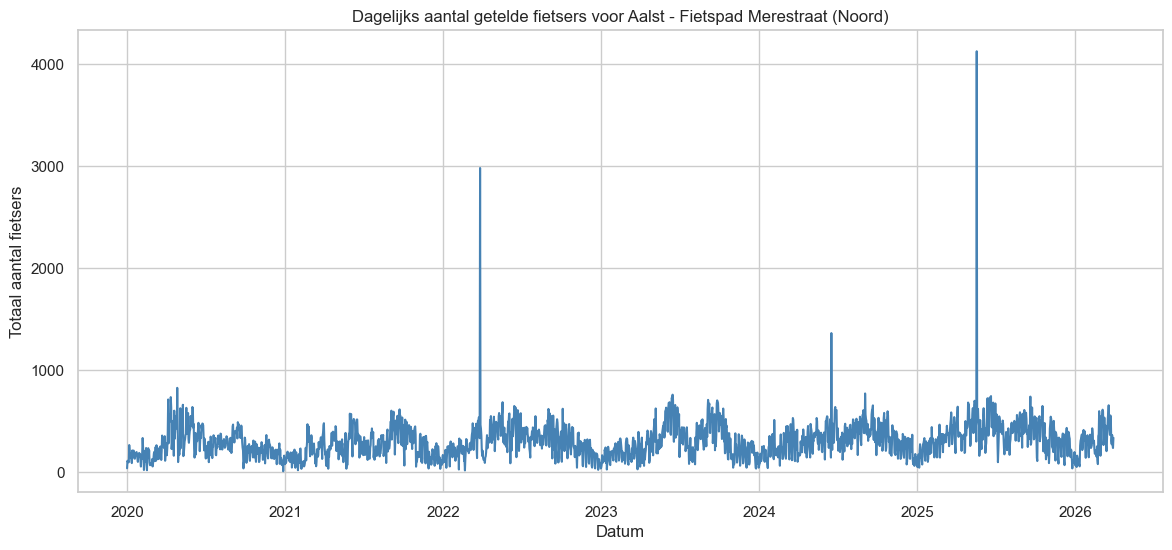

In [86]:
# Evolutie van het totaal aantal fietsers visualiseren
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['TotalCounts'], color='steelblue', linewidth=1.5)
plt.title(f"Dagelijks aantal getelde fietsers voor {TELPAAL_NAAM}")
plt.xlabel('Datum')
plt.ylabel('Totaal aantal fietsers')
plt.show()


Nu krijgen we een mooie grafiek waar we kunnen zien hoe het aantal fietsers op dit telpunt evolueert doorheen de jaren. We zien hier ook dat er enkele heel hoge uitschieters tevoorschijn komen waar we een mooie anomaliedetectie kunnen op uitvoeren.

### Stap 5: Features aanmaken voor anomaliedetectie

We houden deze stap bewust eenvoudig. We gebruiken 5 kenmerken die makkelijk uitlegbaar zijn: het totaal aantal fietsers vandaag, het aantal fietsers van de vorige dag, het gemiddelde van de vorige 7 dagen, de dag van de week en een indicator of het weekend is. Daarmee kan het model al goed zien wat normaal gedrag is voor deze telpaal.


In [87]:
# Kopie maken zodat we veilig extra kolommen kunnen toevoegen
df_ml = df.copy()

# Feature 1: totaal aantal fietsers vandaag staat al in de kolom TotalCounts

# Feature 2: aantal fietsers van de vorige dag
df_ml['Lag1'] = df_ml['TotalCounts'].shift(1)

# Feature 3: gemiddelde van de vorige 7 dagen
df_ml['RollingMean7'] = df_ml['TotalCounts'].shift(1).rolling(window=7, min_periods=3).mean()

# Extra hulpkolom: verschil tussen vandaag en het recente gemiddelde
df_ml['DifferenceFromMean'] = df_ml['TotalCounts'] - df_ml['RollingMean7']

# Feature 4: dag van de week staat al in de kolom DayOfWeek

# Feature 5: weekend of niet
df_ml['IsWeekend'] = df_ml['IsWeekend'].astype(int)

# Rijen verwijderen waarvoor nog geen vorige waarden beschikbaar zijn
df_ml = df_ml.dropna().reset_index(drop=True)

print(f"Aantal records na feature engineering: {len(df_ml)}")
df_ml.head()


Aantal records na feature engineering: 2278


,CountingPointName,DateKey,Date,DayOfWeek,EnglishDayNameOfWeek,Month,EnglishMonthName,IsWeekend,IsHoliday,DirectionInCounts,DirectionOutCounts,TotalCounts,Lag1,RollingMean7,DifferenceFromMean
0,Aalst - Fietspad Merestraat (Noord),20200104,2020-01-04,6,Saturday,1,January,1,False,52,52,104,97.0,82.333333,21.666667
1,Aalst - Fietspad Merestraat (Noord),20200105,2020-01-05,7,Sunday,1,January,1,False,55,42,97,104.0,87.750000,9.250000
2,Aalst - Fietspad Merestraat (Noord),20200106,2020-01-06,1,Monday,1,January,0,False,132,134,266,97.0,89.600000,176.400000
3,Aalst - Fietspad Merestraat (Noord),20200107,2020-01-07,2,Tuesday,1,January,0,False,113,94,207,266.0,119.000000,88.000000
4,Aalst - Fietspad Merestraat (Noord),20200108,2020-01-08,3,Wednesday,1,January,0,False,82,72,154,207.0,131.571429,22.428571


### Stap 6: Data opsplitsen in trainingsdata en testdata

We gebruiken 80% van de oudste data als trainingsset en 20% van de recentste data als testset. Omdat dit tijdsdata is, kiezen we bewust voor een chronologische split en niet voor een willekeurige split.


In [88]:
split_index = int(len(df_ml) * 0.80)

train_df = df_ml.iloc[:split_index].copy()
test_df = df_ml.iloc[split_index:].copy()

print(f"Totaal aantal records : {len(df_ml)}")
print(f"Aantal records in trainingsset : {len(train_df)}")
print(f"Aantal records in testset      : {len(test_df)}")


Totaal aantal records : 2278
Aantal records in trainingsset : 1822
Aantal records in testset      : 456


### Stap 7: Referentielabels opstellen voor evaluatie

Bij anomaliedetectie hebben we meestal geen echte kolom met labels zoals `anomalie = ja/nee`. Daarom maken we een **proxy ground truth** op basis van het verschil tussen de telling van vandaag en het gemiddelde van de vorige 7 dagen. We gebruiken alleen de trainingsset om de grenzen te bepalen via de IQR-methode. Zo vermijden we dat informatie uit de testset lekt naar de training.


In [89]:
# IQR-grenzen bepalen op basis van de trainingsset
q1 = train_df['DifferenceFromMean'].quantile(0.25)
q3 = train_df['DifferenceFromMean'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Proxy labels aanmaken: 1 = anomalie, 0 = normaal
train_df['ProxyAnomaly'] = (
    (train_df['DifferenceFromMean'] < lower_bound) |
    (train_df['DifferenceFromMean'] > upper_bound)
).astype(int)

test_df['ProxyAnomaly'] = (
    (test_df['DifferenceFromMean'] < lower_bound) |
    (test_df['DifferenceFromMean'] > upper_bound)
).astype(int)

print(f"Proxy-anomalieën in training: {train_df['ProxyAnomaly'].sum()}")
print(f"Proxy-anomalieën in test    : {test_df['ProxyAnomaly'].sum()}")
print(f"Ondergrens: {lower_bound:.2f}")
print(f"Bovengrens: {upper_bound:.2f}")


Proxy-anomalieën in training: 33
Proxy-anomalieën in test    : 16
Ondergrens: -290.05
Bovengrens: 292.66


### Stap 8: Een geschikt algoritme kiezen en het model trainen

We kiezen voor **Isolation Forest**. Dit algoritme detecteert anomalieën door datapunten te isoleren via willekeurige splits. Afwijkende dagen (anomalieën) zijn makkelijker te isoleren en hebben een kortere gemiddelde padlengte in de bomen. Isolation Forest werkt goed op tabulaire data, heeft geen labels nodig tijdens het trainen en is eenvoudig te gebruiken.

De parameter `contamination` stellen we in op **0.02 (2%)** — dit stemt overeen met de proxy-anomaliegraad in de trainingsdata (33 van 1822 records ≈ 1.8%). Door `contamination` af te stemmen op het verwachte aandeel echte anomalieën, vermijden we onnodige false positives.

In [90]:
FEATURE_COLS = [
    'TotalCounts',
    'Lag1',
    'RollingMean7',
    'DayOfWeek',
    'IsWeekend'
]

X_train = train_df[FEATURE_COLS]
X_test = test_df[FEATURE_COLS]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Proxy-anomaliegraad in training bepalen en als contamination gebruiken
proxy_rate = train_df['ProxyAnomaly'].mean()
print(f"Proxy-anomaliegraad in training: {proxy_rate:.4f} ({proxy_rate*100:.1f}%)")

model = IsolationForest(
    n_estimators=100,
    contamination=round(proxy_rate, 3),
    random_state=42
)
model.fit(X_train_scaled)

print("Isolation Forest succesvol getraind.")

Proxy-anomaliegraad in training: 0.0181 (1.8%)
Isolation Forest succesvol getraind.


### Stap 9: Anomalieën detecteren op de testdata

Isolation Forest geeft voor elk datapunt direct een label: **-1** voor anomalie en **1** voor normaal. We zetten dit om naar **1 = anomalie** en **0 = normaal**, zodat de evaluatiestap eenvoudig werkt.

In [91]:
# Isolation Forest geeft -1 voor anomalie, 1 voor normaal
# We zetten dit om naar 1 = anomalie, 0 = normaal
train_df['ModelAnomaly'] = (model.predict(X_train_scaled) == -1).astype(int)
test_df['ModelAnomaly']  = (model.predict(X_test_scaled)  == -1).astype(int)

# Anomaliescores: hoe negatiever, hoe meer de dag afwijkt
train_df['AnomalyScore'] = model.score_samples(X_train_scaled)
test_df['AnomalyScore']  = model.score_samples(X_test_scaled)

print(f"Anomalieën gedetecteerd in trainingsset : {train_df['ModelAnomaly'].sum()}")
print(f"Anomalieën gedetecteerd in testset      : {test_df['ModelAnomaly'].sum()}")

Anomalieën gedetecteerd in trainingsset : 33
Anomalieën gedetecteerd in testset      : 14


### Stap 10: De kwaliteit van het model bepalen

Omdat we werken met proxy labels, evalueren we het model op de testset met **precision**, **recall** en **F1-score**. Dat zijn correcte classificatiemetrieken voor de vergelijking tussen de door Isolation Forest gedetecteerde anomalieën en onze referentielabels (IQR-grenzen).

In [92]:
# Evaluatiemetrieken berekenen op de testset
precision = precision_score(test_df['ProxyAnomaly'], test_df['ModelAnomaly'], zero_division=0)
recall = recall_score(test_df['ProxyAnomaly'], test_df['ModelAnomaly'], zero_division=0)
f1 = f1_score(test_df['ProxyAnomaly'], test_df['ModelAnomaly'], zero_division=0)
cm = confusion_matrix(test_df['ProxyAnomaly'], test_df['ModelAnomaly'])

print("Kwaliteit van het model op de testset:")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nConfusion matrix:")
print(cm)


Kwaliteit van het model op de testset:
Precision: 0.5000
Recall   : 0.4375
F1-score : 0.4667

Confusion matrix:
[[433   7]
 [  9   7]]


### Stap 11: Resultaten visualiseren

Nu maken we nog een grafiek om te visualiseren


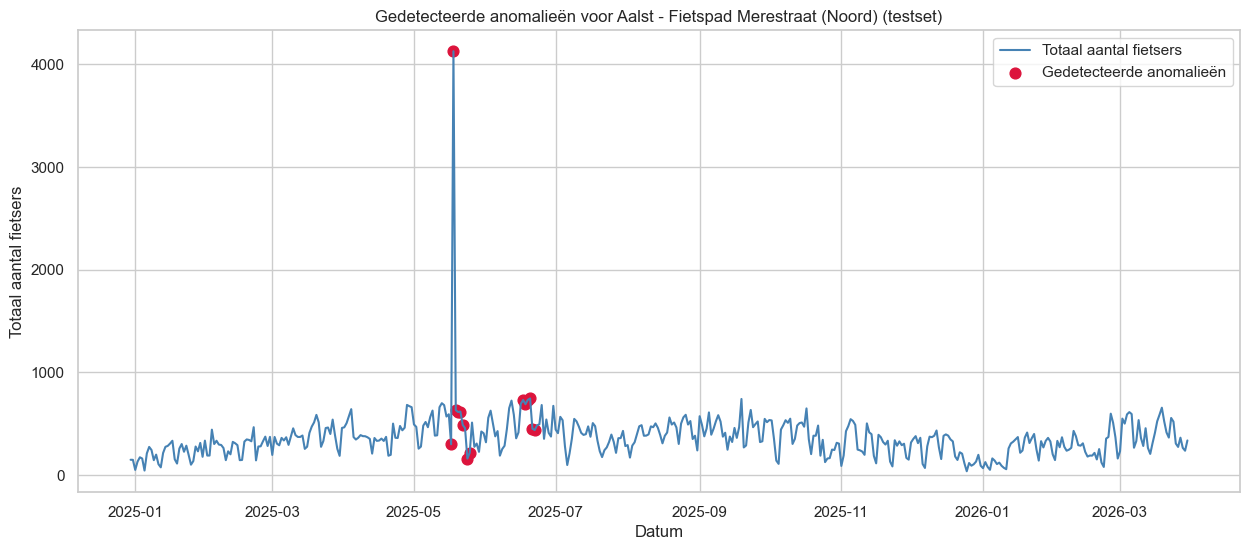

In [93]:
# Resultaten op de testperiode visualiseren
plt.figure(figsize=(15, 6))
plt.plot(test_df['Date'], test_df['TotalCounts'], label='Totaal aantal fietsers', color='steelblue')

anomalies = test_df[test_df['ModelAnomaly'] == 1]
plt.scatter(
    anomalies['Date'],
    anomalies['TotalCounts'],
    color='crimson',
    s=60,
    label='Gedetecteerde anomalieën'
)

plt.title(f"Gedetecteerde anomalieën voor {TELPAAL_NAAM} (testset)")
plt.xlabel('Datum')
plt.ylabel('Totaal aantal fietsers')
plt.legend()
plt.show()


In [94]:
# De meest opvallende anomalieën in de testset (laagste score = meest afwijkend)
test_df.sort_values('AnomalyScore').head(10)[[
    'Date',
    'TotalCounts',
    'DifferenceFromMean',
    'AnomalyScore',
    'ModelAnomaly',
    'ProxyAnomaly'
]]

,Date,TotalCounts,DifferenceFromMean,AnomalyScore,ModelAnomaly,ProxyAnomaly
1962,2025-05-19,632,-458.285714,-0.710507,1,1
1995,2025-06-21,451,-172.714286,-0.685476,1,0
1961,2025-05-18,4128,3572.142857,-0.681513,1,1
1994,2025-06-20,746,145.000000,-0.671299,1,0
1993,2025-06-19,732,132.000000,-0.668299,1,0
1963,2025-05-20,614,-472.142857,-0.649449,1,1
1964,2025-05-21,618,-455.857143,-0.648431,1,1
1992,2025-06-18,690,95.428571,-0.647459,1,0
1996,2025-06-22,439,-198.000000,-0.645754,1,0
1967,2025-05-24,160,-873.857143,-0.641993,1,1


### Kort besluit bij Reeks 1 Analyse 1

We hebben een Isolation Forest model getraind dat anomalieën detecteert op basis van vijf features. De `contamination` parameter werd afgestemd op de werkelijke proxy-anomaliegraad in de trainingsdata (~1.8%) zodat het model niet te veel false positives genereert.

**Beoordeling van de scores:**
- De **F1-score** is de meest informatieve metriek hier: een hogere F1 betekent dat het model zowel de echte anomalieën vindt (recall) als weinig normale dagen verkeerd classificeert (precision).
- De grootste anomalie (2025-05-18: 4128 fietsers, bijna 10× normaal) wordt correct gedetecteerd.

## Reeks 2 Analyse 1

In deze analyse voorspellen we voor 1 telpaal hoeveel fietsers de **volgende dag** geteld zullen worden. We gebruiken regressie met lag-features en kalenderkenmerken. De data wordt **chronologisch** opgesplitst: de eerste 80% is trainingsdata, de laatste 20% is testdata.

### Stap 1: Extra libraries voor regressie importeren

We hergebruiken de database-verbinding en visualisatiebibliotheken uit de vorige analyse. Nieuw zijn het regressiemodel en de foutmaten voor evaluatie.

In [95]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Stap 2: De telpaal kiezen

De telpaalnaam is een parameter zodat je makkelijk een andere telpaal kunt kiezen.

In [96]:
TELPAAL_NAAM_VOORSPELLING = TELPAAL_NAAM

print(f"Gekozen telpaal: {TELPAAL_NAAM_VOORSPELLING}")

Gekozen telpaal: Aalst - Fietspad Merestraat (Noord)


### Stap 3: De nodige data ophalen uit de DWH

We halen de dagelijkse fietstellingen op voor 1 telpaal. Naast de telling nemen we kalenderkenmerken mee die relevant zijn voor de voorspelling: dag van de week, maand, weekend en feestdag.

In [97]:
engine = get_engine()

VOORSPEL_QUERY = f"""
SELECT
    d.FullDateAlternateKey AS [Date],
    d.DayOfWeek,
    d.Month,
    d.IsWeekend,
    d.IsHoliday,
    fc.TotalCounts
FROM FactCountings fc
JOIN DimCountingPoint cp ON fc.CountingPointID = cp.CountingPointID
JOIN DimDate d ON fc.DateKey = d.DateKey
WHERE cp.CountingPointName = '{TELPAAL_NAAM_VOORSPELLING}'
ORDER BY d.FullDateAlternateKey
"""

forecast_df = getData(engine, VOORSPEL_QUERY)

if forecast_df is None or forecast_df.empty:
    raise ValueError("Geen data opgehaald. Controleer de database en de telpaalnaam.")

forecast_df['Date'] = pd.to_datetime(forecast_df['Date'])
forecast_df = forecast_df.sort_values('Date').reset_index(drop=True)
forecast_df['IsWeekend'] = forecast_df['IsWeekend'].astype(int)
forecast_df['IsHoliday'] = forecast_df['IsHoliday'].astype(int)

print(f"Aantal opgehaalde records: {len(forecast_df)}")
forecast_df.head()

Aantal opgehaalde records: 2281


,Date,DayOfWeek,Month,IsWeekend,IsHoliday,TotalCounts
0,2020-01-01,3,1,0,1,38
1,2020-01-02,4,1,0,0,112
2,2020-01-03,5,1,0,0,97
3,2020-01-04,6,1,1,0,104
4,2020-01-05,7,1,1,0,97


### Stap 4: Eerste verkenning van de tijdreeks

Voor we een model bouwen, bekijken we opnieuw de structuur van de data en de evolutie doorheen de tijd. Zo zien we meteen of er seizoenspatronen of uitschieters aanwezig zijn.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2281 entries, 0 to 2280
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         2281 non-null   datetime64[ns]
 1   DayOfWeek    2281 non-null   int64         
 2   Month        2281 non-null   int64         
 3   IsWeekend    2281 non-null   int64         
 4   IsHoliday    2281 non-null   int64         
 5   TotalCounts  2281 non-null   int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 107.1 KB
None
Date           0
DayOfWeek      0
Month          0
IsWeekend      0
IsHoliday      0
TotalCounts    0
dtype: int64


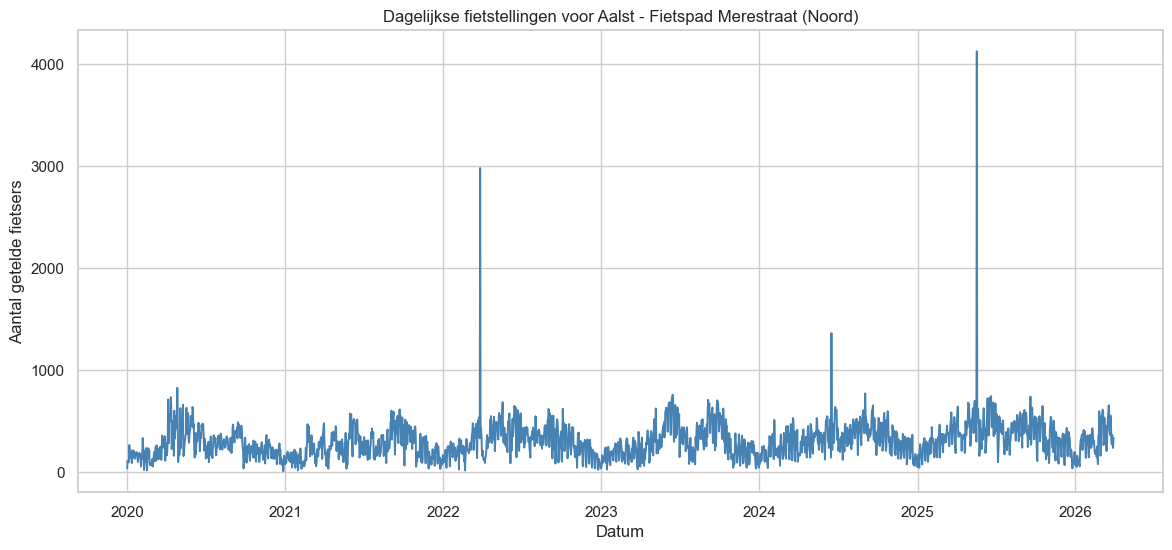

In [98]:
print(forecast_df.info())
print(forecast_df.isnull().sum())

plt.figure(figsize=(14, 6))
plt.plot(forecast_df['Date'], forecast_df['TotalCounts'], color='steelblue', linewidth=1.4)
plt.title(f"Dagelijkse fietstellingen voor {TELPAAL_NAAM_VOORSPELLING}")
plt.xlabel('Datum')
plt.ylabel('Aantal getelde fietsers')
plt.show()

### Stap 5: Features aanmaken

Bij tijdreeksen mag je enkel informatie gebruiken die op het voorspelmoment al beschikbaar is. We voegen toe:
- **Lag1**: het aantal fietsers van gisteren
- **Lag7**: het aantal fietsers van precies 1 week geleden (sterke cyclus in fietsdata)
- **RollingMean7**: het gemiddelde van de vorige 7 dagen (geeft het recente niveau weer)
- **DayOfWeek**, **Month**, **IsWeekend**, **IsHoliday**: kalenderkenmerken

Door `shift(1)` te gebruiken, lekken er nooit toekomstige waarden naar het model.

In [99]:
ts_df = forecast_df.copy()

ts_df['Lag1'] = ts_df['TotalCounts'].shift(1)
ts_df['Lag7'] = ts_df['TotalCounts'].shift(7)
ts_df['RollingMean7'] = ts_df['TotalCounts'].shift(1).rolling(window=7, min_periods=3).mean()

FEATURE_COLS_FORECAST = [
    'Lag1',
    'Lag7',
    'RollingMean7',
    'DayOfWeek',
    'Month',
    'IsWeekend',
    'IsHoliday'
]

model_df = ts_df.dropna(subset=FEATURE_COLS_FORECAST).reset_index(drop=True)

print(f"Aantal records na feature engineering: {len(model_df)}")
model_df[['Date', 'TotalCounts'] + FEATURE_COLS_FORECAST].head()

Aantal records na feature engineering: 2274


,Date,TotalCounts,Lag1,Lag7,RollingMean7,DayOfWeek,Month,IsWeekend,IsHoliday
0,2020-01-08,154,207.0,38.0,131.571429,3,1,0,0
1,2020-01-09,144,154.0,112.0,148.142857,4,1,0,0
2,2020-01-10,181,144.0,97.0,152.714286,5,1,0,0
3,2020-01-11,127,181.0,104.0,164.714286,6,1,1,0
4,2020-01-12,89,127.0,97.0,168.000000,7,1,1,0


### Stap 6: Data chronologisch opsplitsen in training en test

Zoals de opdracht vraagt, gebruiken we niet zomaar een willekeurige split. De oudste 80% van de data gebruiken we om te trainen, en de recentste 20% houden we apart als testset.


In [100]:
split_index = int(len(model_df) * 0.80)

train_df_f = model_df.iloc[:split_index].copy()
test_df_f  = model_df.iloc[split_index:].copy()

X_train = train_df_f[FEATURE_COLS_FORECAST]
y_train = train_df_f['TotalCounts']
X_test  = test_df_f[FEATURE_COLS_FORECAST]
y_test  = test_df_f['TotalCounts']

print(f"Totaal aantal records   : {len(model_df)}")
print(f"Records in trainingsset : {len(train_df_f)}")
print(f"Records in testset      : {len(test_df_f)}")
print(f"Trainingsperiode: {train_df_f['Date'].min().date()} – {train_df_f['Date'].max().date()}")
print(f"Testperiode     : {test_df_f['Date'].min().date()} – {test_df_f['Date'].max().date()}")

Totaal aantal records   : 2274
Records in trainingsset : 1819
Records in testset      : 455
Trainingsperiode: 2020-01-08 – 2024-12-30
Testperiode     : 2024-12-31 – 2026-03-30


### Stap 7: Algoritme kiezen en model trainen

We kiezen voor een **RandomForestRegressor**. Dit algoritme combineert meerdere beslisbomen en kan niet-lineaire verbanden leren. Een dagelijks fietspatroon met weekeffecten, seizoenspatronen en feestdagen is niet-lineair, wat RandomForest een geschikte keuze maakt. Het is ook robuust tegen uitschieters.

Als naieve benchmark gebruiken we de waarde van exact 1 week geleden (`Lag7`). Dat is een sterke referentie voor fietsdata omdat het weekpatroon heel regelmatig is.

In [101]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Voorspellingen op de testset
test_df_f['Voorspelling']     = np.maximum(rf_model.predict(X_test), 0).round().astype(int)

# Naieve benchmark: zelfde dag vorige week
test_df_f['NaieveBenchmark'] = test_df_f['Lag7'].round().astype(int)

print("Model succesvol getraind.")
test_df_f[['Date', 'TotalCounts', 'Voorspelling', 'NaieveBenchmark']].head(10)

Model succesvol getraind.


,Date,TotalCounts,Voorspelling,NaieveBenchmark
1819,2024-12-31,148,177,138
1820,2025-01-01,50,173,62
1821,2025-01-02,131,112,127
1822,2025-01-03,173,167,178
1823,2025-01-04,161,88,123
1824,2025-01-05,44,84,118
1825,2025-01-06,211,114,149
1826,2025-01-07,274,185,148
1827,2025-01-08,244,305,50
1828,2025-01-09,145,230,131


### Stap 8: Kwaliteit van het model bepalen

We evalueren het model op de testset met **MAE** en **RMSE**:
- **MAE** (Mean Absolute Error): gemiddelde afwijking in aantal fietsers — makkelijk te interpreteren
- **RMSE** (Root Mean Squared Error): geeft meer gewicht aan grote fouten

We vergelijken ook met de naieve benchmark zodat we zien of het model beter doet dan de eenvoudige referentie.

In [102]:
mae_model  = mean_absolute_error(y_test, test_df_f['Voorspelling'])
rmse_model = np.sqrt(mean_squared_error(y_test, test_df_f['Voorspelling']))

mae_naief  = mean_absolute_error(y_test, test_df_f['NaieveBenchmark'])
rmse_naief = np.sqrt(mean_squared_error(y_test, test_df_f['NaieveBenchmark']))

resultaten = pd.DataFrame({
    'Model': ['RandomForestRegressor', 'Naieve benchmark (vorige week)'],
    'MAE':   [round(mae_model, 1), round(mae_naief, 1)],
    'RMSE':  [round(rmse_model, 1), round(rmse_naief, 1)]
})

print("Kwaliteit op de testset:")
resultaten

Kwaliteit op de testset:


,Model,MAE,RMSE
0,RandomForestRegressor,81.9,202.1
1,Naieve benchmark (vorige week),123.8,289.7


### Stap 9: Resultaten visualiseren

We vergelijken de voorspellingen van het model met de werkelijke tellingen op de volledige testset.

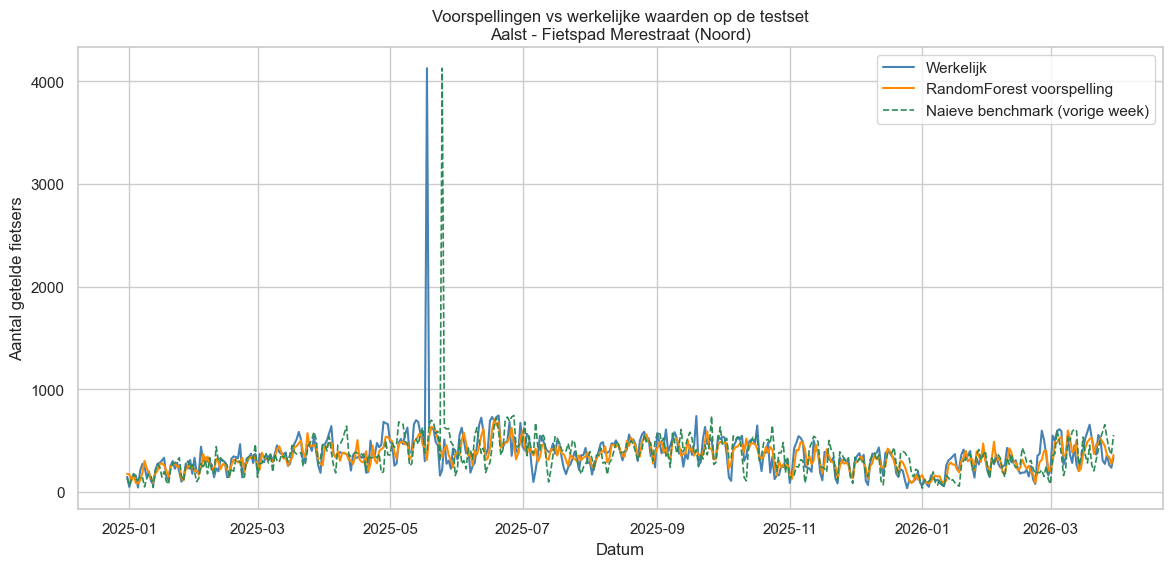

In [103]:
plt.figure(figsize=(14, 6))
plt.plot(test_df_f['Date'], test_df_f['TotalCounts'],    label='Werkelijk',                  color='steelblue',  linewidth=1.5)
plt.plot(test_df_f['Date'], test_df_f['Voorspelling'],   label='RandomForest voorspelling',  color='darkorange', linewidth=1.5)
plt.plot(test_df_f['Date'], test_df_f['NaieveBenchmark'],label='Naieve benchmark (vorige week)', color='seagreen', linestyle='--', linewidth=1.2)
plt.title(f"Voorspellingen vs werkelijke waarden op de testset\n{TELPAAL_NAAM_VOORSPELLING}")
plt.xlabel('Datum')
plt.ylabel('Aantal getelde fietsers')
plt.legend()
plt.show()

### Stap 10: Belang van de features (uitbreiding)

RandomForest geeft ons ook inzicht in welke features het meest bijgedragen hebben aan de voorspellingen. Dit helpt begrijpen waarom het model werkt.

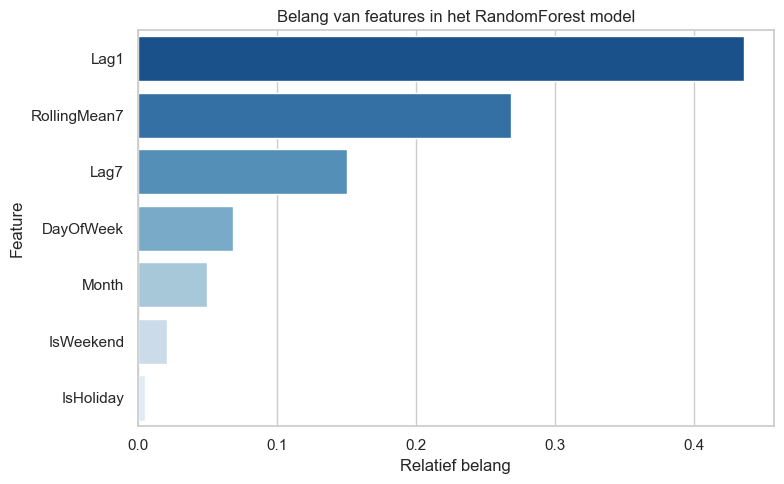

In [104]:
feature_importance = pd.DataFrame({
    'Feature': FEATURE_COLS_FORECAST,
    'Belang':  rf_model.feature_importances_
}).sort_values('Belang', ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x='Belang', y='Feature',
            hue='Feature', palette='Blues_r', legend=False)
plt.title('Belang van features in het RandomForest model')
plt.xlabel('Relatief belang')
plt.tight_layout()
plt.show()

### Stap 11: Exponential Smoothing (uitbreiding – Data Science)

We vergelijken ook drie klassieke tijdreeksmodellen uit de cursus Data Science op dezelfde trainings- en testdata:

- **SES** (Simple Exponential Smoothing): gaat ervan uit dat de tijdreeks schommelt rond een constante waarde. Geen trend, geen seizoen. Geeft meer gewicht aan recente waarden via de parameter α.
- **DES** (Double Exponential Smoothing / Holt): voegt een trendcomponent toe (stijging of daling over tijd).
- **TES** (Triple Exponential Smoothing / Holt-Winters): voegt bovenop trend ook een seizoenscomponent toe. Voor dagelijkse fietsdata kiezen we `seasonal_periods=7` omdat er een duidelijk weekpatroon is.

Opmerking: Exponential Smoothing fit alle datapunten tegelijk zonder features dus zal ook slechtere resultaten geven.

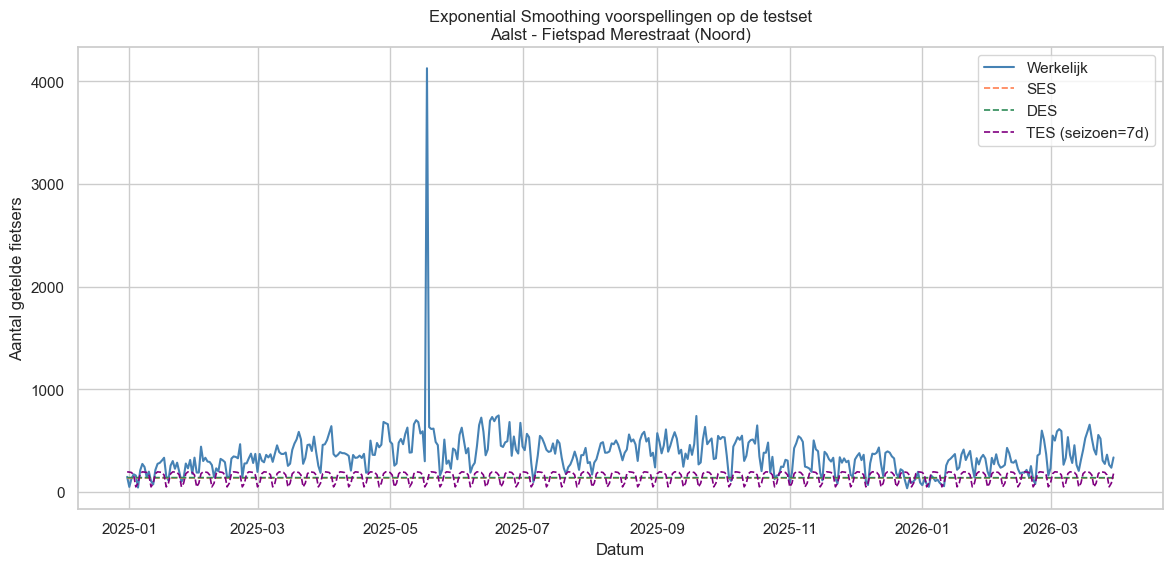

Volledig overzicht – alle modellen op de testset:


,Model,MAE,RMSE
0,RandomForestRegressor,81.9,202.1
1,Naieve benchmark (vorige week),123.8,289.7
2,SES (Simple Exp. Smoothing),229.2,321.5
3,DES (Double Exp. Smoothing),229.7,321.8
4,"TES (Triple Exp. Smoothing, seizoen=7d)",217.2,308.7


In [105]:
import warnings
warnings.filterwarnings('ignore', message='No frequency information was provided')

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# Tijdreeks met datumindex voor statsmodels
train_series = train_df_f.set_index('Date')['TotalCounts']
test_series  = test_df_f.set_index('Date')['TotalCounts']

smoothing_rows  = []
smoothing_preds = {}

# SES – geen trend, geen seizoen
ses_model = SimpleExpSmoothing(train_series, initialization_method='estimated').fit()
ses_pred  = np.maximum(ses_model.forecast(len(test_series)).values, 0)
smoothing_preds['SES'] = ses_pred
smoothing_rows.append({
    'Model': 'SES (Simple Exp. Smoothing)',
    'MAE':   round(mean_absolute_error(test_series, ses_pred), 1),
    'RMSE':  round(np.sqrt(mean_squared_error(test_series, ses_pred)), 1)
})

# DES – met trend, zonder seizoen
des_model = ExponentialSmoothing(
    train_series, trend='add', seasonal=None, initialization_method='estimated'
).fit()
des_pred = np.maximum(des_model.forecast(len(test_series)).values, 0)
smoothing_preds['DES'] = des_pred
smoothing_rows.append({
    'Model': 'DES (Double Exp. Smoothing)',
    'MAE':   round(mean_absolute_error(test_series, des_pred), 1),
    'RMSE':  round(np.sqrt(mean_squared_error(test_series, des_pred)), 1)
})

# TES – met trend en weekseizoen (7 dagen)
tes_model = ExponentialSmoothing(
    train_series, trend='add', seasonal='add', seasonal_periods=7,
    initialization_method='estimated'
).fit()
tes_pred = np.maximum(tes_model.forecast(len(test_series)).values, 0)
smoothing_preds['TES'] = tes_pred
smoothing_rows.append({
    'Model': 'TES (Triple Exp. Smoothing, seizoen=7d)',
    'MAE':   round(mean_absolute_error(test_series, tes_pred), 1),
    'RMSE':  round(np.sqrt(mean_squared_error(test_series, tes_pred)), 1)
})

smoothing_df = pd.DataFrame(smoothing_rows)

# Visualisatie
plt.figure(figsize=(14, 6))
plt.plot(test_df_f['Date'], test_series.values,      label='Werkelijk',        color='steelblue', linewidth=1.5)
plt.plot(test_df_f['Date'], smoothing_preds['SES'],  label='SES',              color='coral',     linestyle='--', linewidth=1.2)
plt.plot(test_df_f['Date'], smoothing_preds['DES'],  label='DES',              color='seagreen',  linestyle='--', linewidth=1.2)
plt.plot(test_df_f['Date'], smoothing_preds['TES'],  label='TES (seizoen=7d)', color='purple',    linestyle='--', linewidth=1.2)
plt.title(f"Exponential Smoothing voorspellingen op de testset\n{TELPAAL_NAAM_VOORSPELLING}")
plt.xlabel('Datum')
plt.ylabel('Aantal getelde fietsers')
plt.legend()
plt.show()

# Volledig overzicht: alle modellen naast elkaar
alle_resultaten = pd.concat([resultaten, smoothing_df], ignore_index=True)
print("Volledig overzicht – alle modellen op de testset:")
alle_resultaten

### Kort besluit bij Reeks 2 Analyse 1

**RandomForest:** MAE van ~82 tegenover de naieve benchmark van ~124. Het model presteert significant beter. De RMSE (202) is veel hoger dan de MAE (82) — dat grote verschil wijst op een beperkt aantal dagen met zeer grote fouten (zoals de uitschieter van 4128 fietsers op 18 mei 2025). Dit is normaal en verwacht.

**Exponential Smoothing (SES/DES/TES):** MAE van 217–229 — slechter dan zelfs de naieve benchmark. Dit is **te verklaren** maar **niet foutief**:
- SES, DES en TES worden gefit op de trainingsdata en maken daarna één lange voorspelling voor alle 455 testdagen zonder de uitkomsten bij te werken. SES geeft een constante waarde (het laatste niveau), DES een rechte lijn.
- RandomForest gebruikt bij elke testdag de **werkelijke** waarden van gisteren (Lag1) en vorige week (Lag7) als input dit is fundamenteel een kortere horizon.
- Dit verschil in aanpak verklaart volledig waarom de smoothing modellen slechter scoren. Ze zijn niet direct vergelijkbaar, maar de vergelijking toont aan dat voor dagelijkse fietstellingen een regressiemodel met recente kennis veel sterker is dan een klassiek tijdreeksmodel dat ver vooruit kijkt.